## Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, classification_report)
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## Загрузка данных

In [2]:
iris = load_iris()

In [3]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [4]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [5]:
iris_df = pd.DataFrame(iris.data)

In [6]:
# Делаем имена колонок такие же, как имена переменных:
iris_df.columns = iris.feature_names
# Добавляем столбец с целевой переменной:
iris_df['target'] = iris.target
# Для наглядности добавляем столбец с сортами:
iris_df['name'] = iris_df.target.apply(lambda x : iris.target_names[x])
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [7]:
# информация о наборе данных
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   name               150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [8]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## Обучение

In [9]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(iris_df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']], iris_df['target'], test_size=0.3, random_state=19)

### Стекинг

In [10]:
# Базовые модели
base_models = [
    ('svc', SVC(probability=True, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=3, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42))
]

# Мета-модель
meta_model = LogisticRegression()

# Создаем стекинг
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)

stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)

print('Stacking Classifier Report:')
print(classification_report(y_test, y_pred_stack))

Stacking Classifier Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.89      1.00      0.94        16
           2       1.00      0.87      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



### RandomForestClassifier

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print('Random Forest Report:')
print(classification_report(y_test, y_pred_rf))

Random Forest Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.84      1.00      0.91        16
           2       1.00      0.80      0.89        15

    accuracy                           0.93        45
   macro avg       0.95      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



### Нейронная модель

In [12]:
# Создаем модель
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(4,)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Обучаем с использованием GPU
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.3238 - loss: 1.4612 - val_accuracy: 0.3556 - val_loss: 1.1144
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3619 - loss: 1.3532 - val_accuracy: 0.3556 - val_loss: 1.0138
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3333 - loss: 1.2088 - val_accuracy: 0.5778 - val_loss: 0.9325
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3619 - loss: 1.2485 - val_accuracy: 0.7778 - val_loss: 0.8843
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5238 - loss: 0.9472 - val_accuracy: 0.8444 - val_loss: 0.8480
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4381 - loss: 1.1126 - val_accuracy: 0.8889 - val_loss: 0.8159
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5143 - loss: 0.9257 - val_accuracy: 1.0000 - val_loss: 0.7779
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5905 - loss: 0.8741 - val_accuracy: 0.8000 - val_loss

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


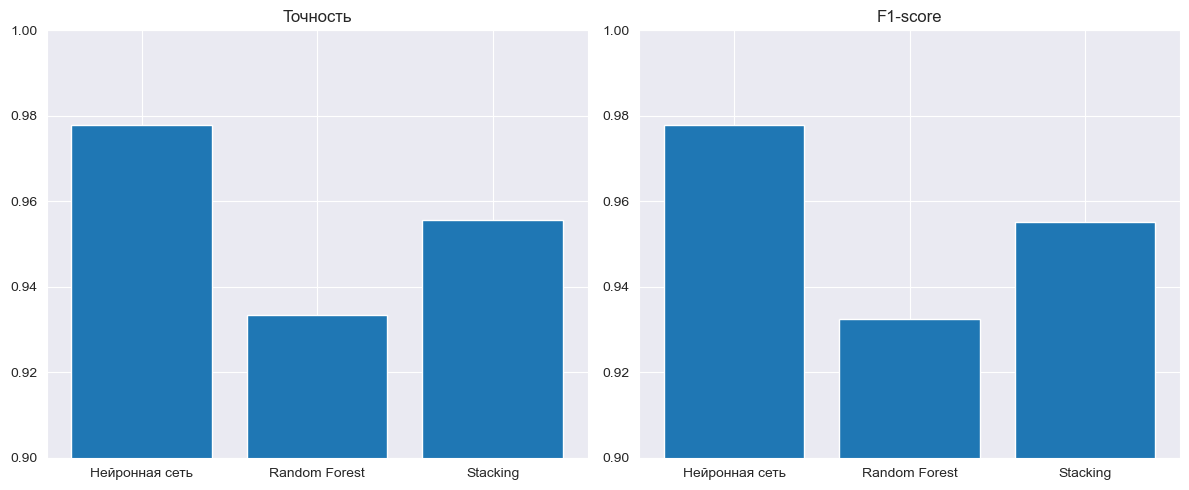

In [13]:
# Сбор метрик
results = {
    'Нейронная сеть': {
        'accuracy': accuracy_score(y_test, np.argmax(model.predict(X_test), axis=1)),
        'f1': f1_score(y_test, np.argmax(model.predict(X_test), axis=1), average='weighted')
    },
    'Random Forest': {
        'accuracy': accuracy_score(y_test, y_pred_rf),
        'f1': f1_score(y_test, y_pred_rf, average='weighted')
    },
    'Stacking': {
        'accuracy': accuracy_score(y_test, y_pred_stack),
        'f1': f1_score(y_test, y_pred_stack, average='weighted')
    }
}

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Точность
accuracies = [results[model]['accuracy'] for model in results.keys()]
axes[0].bar(results.keys(), accuracies,)
axes[0].set_title('Точность')
axes[0].set_ylim([0.9, 1.0])

# F1-score
f1_scores = [results[model]['f1'] for model in results.keys()]
axes[1].bar(results.keys(), f1_scores)
axes[1].set_title('F1-score')
axes[1].set_ylim([0.9, 1.0])

plt.tight_layout()
plt.show()

In [14]:
# Таблица сравнения
df_results = pd.DataFrame(results).T
print(df_results)

                accuracy        f1
Нейронная сеть  0.977778  0.977778
Random Forest   0.933333  0.932487
Stacking        0.955556  0.955275
